### 動的計画法

+ エージェント : ロボット
+ 環境 : 2グリッド
+ 報酬 : -1(壁), 1(🍎), 0
+ 行動 : 左右に移動

```markdown
(例) 5x5グリッド環境による状態価値関数の遷移テーブル

```
| K/S | s1 | s2 | s3 | s4 |
|---|---|---|---|---|
| k | | | | $V_{k}(s4)$ |
| k+1 | | $V_{k+1}(s2)$ | | |
| k+2 | $V_{k+2}(s1)$ | | $V_{k+2}(s3)$ | |
| ... | | | | |
| π | | | | |

* πは最適状態価値
```
```

In [1]:
V = { 'L1': 0.0, 'L2': 0.0 }
new_V = V.copy()
act_left = 0.5
act_right = 0.5

epochs = 100
for i in range(epochs):
    # エージェント(ロボット)が移動して報酬を受け取り、状態価値を更新する
    new_V['L1'] = act_left * (-1 + 0.9 * V['L1']) + act_right * (1 + 0.9 * V['L2'])
    new_V['L2'] = act_left * (0 + 0.9 * V['L1']) + act_right * (-1 + 0.9 * V['L2'])
    V = new_V.copy()
    print(f"{i}: L1: {V['L1']:.3f}, L2: {V['L2']:.3f}")

0: L1: 0.000, L2: -0.500
1: L1: -0.225, L2: -0.725
2: L1: -0.427, L2: -0.927
3: L1: -0.610, L2: -1.110
4: L1: -0.774, L2: -1.274
5: L1: -0.921, L2: -1.421
6: L1: -1.054, L2: -1.554
7: L1: -1.174, L2: -1.674
8: L1: -1.281, L2: -1.781
9: L1: -1.378, L2: -1.878
10: L1: -1.465, L2: -1.965
11: L1: -1.544, L2: -2.044
12: L1: -1.615, L2: -2.115
13: L1: -1.678, L2: -2.178
14: L1: -1.735, L2: -2.235
15: L1: -1.787, L2: -2.287
16: L1: -1.833, L2: -2.333
17: L1: -1.875, L2: -2.375
18: L1: -1.912, L2: -2.412
19: L1: -1.946, L2: -2.446
20: L1: -1.976, L2: -2.476
21: L1: -2.004, L2: -2.504
22: L1: -2.028, L2: -2.528
23: L1: -2.051, L2: -2.551
24: L1: -2.071, L2: -2.571
25: L1: -2.088, L2: -2.588
26: L1: -2.105, L2: -2.605
27: L1: -2.119, L2: -2.619
28: L1: -2.132, L2: -2.632
29: L1: -2.144, L2: -2.644
30: L1: -2.155, L2: -2.655
31: L1: -2.164, L2: -2.664
32: L1: -2.173, L2: -2.673
33: L1: -2.180, L2: -2.680
34: L1: -2.187, L2: -2.687
35: L1: -2.194, L2: -2.694
36: L1: -2.199, L2: -2.699
37: L1: -2.2

In [3]:
# 自動で更新を止める(更新量が閾値以下になった場合に止める)
V = { 'L1': 0.0, 'L2': 0.0 }
new_V = V.copy()
act_left = 0.5
act_right = 0.5

i = 0
epsilon = 0.0001
while True:
    # エージェント(ロボット)が移動して報酬を受け取り、状態価値を更新する
    new_V['L1'] = act_left * (-1 + 0.9 * V['L1']) + act_right * (1 + 0.9 * V['L2'])
    new_V['L2'] = act_left * (0 + 0.9 * V['L1']) + act_right * (-1 + 0.9 * V['L2'])

    # 最大更新量
    delta = abs(new_V['L1'] - V['L1'])
    delta = max(delta, abs(new_V['L2'] - V['L2']))

    V = new_V.copy()
    print(f"{i}: V(L1): {V['L1']:.3f}, V(L2): {V['L2']:.3f}")

    i += 1
    if delta < epsilon:
        break
        
print('fin')

0: V(L1): 0.000, V(L2): -0.500
1: V(L1): -0.225, V(L2): -0.725
2: V(L1): -0.427, V(L2): -0.927
3: V(L1): -0.610, V(L2): -1.110
4: V(L1): -0.774, V(L2): -1.274
5: V(L1): -0.921, V(L2): -1.421
6: V(L1): -1.054, V(L2): -1.554
7: V(L1): -1.174, V(L2): -1.674
8: V(L1): -1.281, V(L2): -1.781
9: V(L1): -1.378, V(L2): -1.878
10: V(L1): -1.465, V(L2): -1.965
11: V(L1): -1.544, V(L2): -2.044
12: V(L1): -1.615, V(L2): -2.115
13: V(L1): -1.678, V(L2): -2.178
14: V(L1): -1.735, V(L2): -2.235
15: V(L1): -1.787, V(L2): -2.287
16: V(L1): -1.833, V(L2): -2.333
17: V(L1): -1.875, V(L2): -2.375
18: V(L1): -1.912, V(L2): -2.412
19: V(L1): -1.946, V(L2): -2.446
20: V(L1): -1.976, V(L2): -2.476
21: V(L1): -2.004, V(L2): -2.504
22: V(L1): -2.028, V(L2): -2.528
23: V(L1): -2.051, V(L2): -2.551
24: V(L1): -2.071, V(L2): -2.571
25: V(L1): -2.088, V(L2): -2.588
26: V(L1): -2.105, V(L2): -2.605
27: V(L1): -2.119, V(L2): -2.619
28: V(L1): -2.132, V(L2): -2.632
29: V(L1): -2.144, V(L2): -2.644
30: V(L1): -2.155, V(

In [4]:
# 上書き方式(DPの基本)
V = { 'L1': 0.0, 'L2': 0.0 }
act_left = 0.5
act_right = 0.5

i = 0
epsilon = 0.0001
while True:
    t = act_left * (-1 + 0.9 * V['L1']) + act_right * (1 + 0.9 * V['L2'])
    delta = abs(t - V['L1'])
    V['L1'] = t

    t = act_left * (0 + 0.9 * V['L1']) + act_right * (-1 + 0.9 * V['L2'])
    delta = max(delta, abs(t - V['L2']))
    V['L2'] = t

    print(f"{i}: V(L1): {V['L1']:.3f}, V(L2): {V['L2']:.3f}")

    i += 1
    if delta < epsilon:
        break

print('fin')

0: V(L1): 0.000, V(L2): -0.500
1: V(L1): -0.225, V(L2): -0.826
2: V(L1): -0.473, V(L2): -1.085
3: V(L1): -0.701, V(L2): -1.304
4: V(L1): -0.902, V(L2): -1.493
5: V(L1): -1.078, V(L2): -1.657
6: V(L1): -1.230, V(L2): -1.799
7: V(L1): -1.363, V(L2): -1.923
8: V(L1): -1.479, V(L2): -2.031
9: V(L1): -1.579, V(L2): -2.125
10: V(L1): -1.667, V(L2): -2.206
11: V(L1): -1.743, V(L2): -2.277
12: V(L1): -1.809, V(L2): -2.339
13: V(L1): -1.866, V(L2): -2.392
14: V(L1): -1.916, V(L2): -2.439
15: V(L1): -1.960, V(L2): -2.479
16: V(L1): -1.998, V(L2): -2.515
17: V(L1): -2.031, V(L2): -2.545
18: V(L1): -2.059, V(L2): -2.572
19: V(L1): -2.084, V(L2): -2.595
20: V(L1): -2.106, V(L2): -2.615
21: V(L1): -2.125, V(L2): -2.633
22: V(L1): -2.141, V(L2): -2.648
23: V(L1): -2.155, V(L2): -2.661
24: V(L1): -2.167, V(L2): -2.673
25: V(L1): -2.178, V(L2): -2.683
26: V(L1): -2.188, V(L2): -2.692
27: V(L1): -2.196, V(L2): -2.699
28: V(L1): -2.203, V(L2): -2.706
29: V(L1): -2.209, V(L2): -2.712
30: V(L1): -2.214, V(

### グリッドワールド環境

In [5]:
# 描画用
import numpy as np
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt

class Renderer:
    def __init__(self, reward_map, goal_state, wall_state):
        self.reward_map = reward_map
        self.goal_state = goal_state
        self.wall_state = wall_state
        self.ys = len(self.reward_map)
        self.xs = len(self.reward_map[0])

        self.ax = None
        self.fig = None
        self.first_flg = True

    def set_figure(self, figsize=None):
        fig = plt.figure(figsize=figsize)
        self.ax = fig.add_subplot(111)
        ax = self.ax
        ax.clear()
        ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
        ax.set_xticks(range(self.xs))
        ax.set_yticks(range(self.ys))
        ax.set_xlim(0, self.xs)
        ax.set_ylim(0, self.ys)
        ax.grid(True)

    def render_v(self, v=None, policy=None, print_value=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax

        if v is not None:
            color_list = ['red', 'white', 'green']
            cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
                'colormap_name', color_list)

            # dict -> ndarray
            v_dict = v
            v = np.zeros(self.reward_map.shape)
            for state, value in v_dict.items():
                v[state] = value

            vmax, vmin = v.max(), v.min()
            vmax = max(vmax, abs(vmin))
            vmin = -1 * vmax
            vmax = 1 if vmax < 1 else vmax
            vmin = -1 if vmin > -1 else vmin

            ax.pcolormesh(np.flipud(v), cmap=cmap, vmin=vmin, vmax=vmax)

        for y in range(ys):
            for x in range(xs):
                state = (y, x)
                r = self.reward_map[y, x]
                if r != 0 and r is not None:
                    txt = 'R ' + str(r)
                    if state == self.goal_state:
                        txt = txt + ' (GOAL)'
                    ax.text(x+.1, ys-y-0.9, txt)

                if (v is not None) and state != self.wall_state:
                    if print_value:
                        offsets = [(0.4, -0.15), (-0.15, -0.3)]
                        key = 0
                        if v.shape[0] > 7: key = 1
                        offset = offsets[key]
                        ax.text(x+offset[0], ys-y+offset[1], "{:12.2f}".format(v[y, x]))

                if policy is not None and state != self.wall_state:
                    actions = policy[state]
                    max_actions = [kv[0] for kv in actions.items() if kv[1] == max(actions.values())]

                    arrows = ["↑", "↓", "←", "→"]
                    offsets = [(0, 0.1), (0, -0.1), (-0.1, 0), (0.1, 0)]
                    for action in max_actions:
                        arrow = arrows[action]
                        offset = offsets[action]
                        if state == self.goal_state:
                            continue
                        ax.text(x+0.45+offset[0], ys-y-0.5+offset[1], arrow)

                if state == self.wall_state:
                    ax.add_patch(plt.Rectangle((x,ys-y-1), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
        plt.show()

    def render_q(self, q, show_greedy_policy=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax
        action_space = [0, 1, 2, 3]

        qmax, qmin = max(q.values()), min(q.values())
        qmax = max(qmax, abs(qmin))
        qmin = -1 * qmax
        qmax = 1 if qmax < 1 else qmax
        qmin = -1 if qmin > -1 else qmin


        color_list = ['red', 'white', 'green']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
            'colormap_name', color_list)

        for y in range(ys):
            for x in range(xs):
                for action in action_space:
                    state = (y, x)
                    r = self.reward_map[y, x]
                    if r != 0 and r is not None:
                        txt = 'R ' + str(r)
                        if state == self.goal_state:
                            txt = txt + ' (GOAL)'
                        ax.text(x+.05, ys-y-0.95, txt)

                    if state == self.goal_state:
                        continue

                    tx, ty = x, ys-y-1

                    action_map = {
                        0: ((0.5+tx, 0.5+ty), (tx+1, ty+1), (tx, ty+1)),
                        1: ((tx, ty), (tx+1, ty), (tx+0.5, ty+0.5)),
                        2: ((tx, ty), (tx+0.5, ty+0.5), (tx, ty+1)),
                        3: ((0.5+tx, 0.5+ty), (tx+1, ty), (tx+1, ty+1)),
                    }
                    offset_map = {
                        0: (0.1, 0.8),
                        1: (0.1, 0.1),
                        2: (-0.2, 0.4),
                        3: (0.4, 0.4),
                    }
                    if state == self.wall_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
                    elif state in self.goal_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0., 1., 0., 1.)))
                    else:

                        tq = q[(state, action)]
                        color_scale = 0.5 + (tq / qmax) / 2  # normalize: 0.0-1.0

                        poly = plt.Polygon(action_map[action],fc=cmap(color_scale))
                        ax.add_patch(poly)

                        offset= offset_map[action]
                        ax.text(tx+offset[0], ty+offset[1], "{:12.2f}".format(tq))
        plt.show()

        if show_greedy_policy:
            policy = {}
            for y in range(self.ys):
                for x in range(self.xs):
                    state = (y, x)
                    qs = [q[state, action] for action in range(4)]  # action_size
                    max_action = np.argmax(qs)
                    probs = {0:0.0, 1:0.0, 2:0.0, 3:0.0}
                    probs[max_action] = 1
                    policy[state] = probs
            self.render_v(None, policy)



In [7]:
import numpy as np

class GridWorld:
    def __init__(self):
        self.action_space = [0,1,2,3]
        self.action_meaning = {
            0: 'UP',   # ↑
            1: 'DOWN', # ↓
            2: 'LEFT', # ←
            3: 'RIGHT' # →
        }

        # 報酬マップ
        self.reward_map = np.array([
            [0, 0, 0, 1.0],
            [0, None, 0, -1.0],
            [0, 0, 0, 0]
        ])

        self.goal_state = (0,3) # reward: 1.0
        self.wall_state = (1,1) # None
        self.start_state = (2,0) # 左下隅
        self.agent_state = self.start_state

    @property
    def height(self):
        return len(self.reward_map)
    
    @property
    def width(self):
        return len(self.reward_map[0])
    
    @property
    def shape(self):
        return self.reward_map.shape
    
    def actions(self):
        return self.action_space
    
    # ジェネレータ
    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield (h,w)

    # 状態遷移関数
    def next_state(self, state, action): # p(s'|s,a)
        # 1. 移動先の場所の計算
        action_move_map = [(-1,0),(1,0),(0,-1),(0,1)] # ↓ ↑ → ←
        move = action_move_map[action]
        next_state = (state[0] + move[0], state[1] + move[1])
        ny, nx = next_state

        # 2. 移動先がグリッドワールドの枠の外か、それとも移動先が壁か?
        if (nx < 0 or nx >= self.width) \
        or (ny < 0 or ny >= self.height):
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state # 3. 状態遷移は決定論的なので関数の結果を返すだけ.
    
    # 報酬関数
    def reward(self, state, action, next_state): # r(s',s,a)
        return self.reward_map[next_state]
    
    def reset(self):
        self.agent_state = self.start_state
        return self.agent_state
    
    # エージェントの状態Sにおける行動
    def step(self, action): # 更新
        state = self.agent_state
        next_state = self.next_state(state, action) # 状態遷移
        reward = self.reward(state, action, next_state) # 得られた報酬
        done = (next_state == self.goal_state) # 収束条件

        self.agent_state = next_state
        return next_state, reward, done
    
    def render_v(self, v=None, policy=None, print_value=True):
        # 状態価値Vの可視化
        renderer = Renderer(self.reward_map,
                                            self.goal_state,
                                            self.wall_state)
        renderer.render_v(v, policy, print_value)

    def render_q(self, q=None, print_value=True):
        # 行動価値Qの可視化
        renderer = Renderer(self.reward_map,
                                          self.goal_state,
                                          self.wall_state)
        renderer.render_q(q, print_value)

In [8]:
env = GridWorld()
print(env.height)
print(env.width)
print(env.shape)

3
4
(3, 4)


In [9]:
for action in env.actions():
    print(action)
print('===')
for state in env.states():
    print(state)

0
1
2
3
===
(0, 0)
(0, 1)
(0, 2)
(0, 3)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(2, 0)
(2, 1)
(2, 2)
(2, 3)


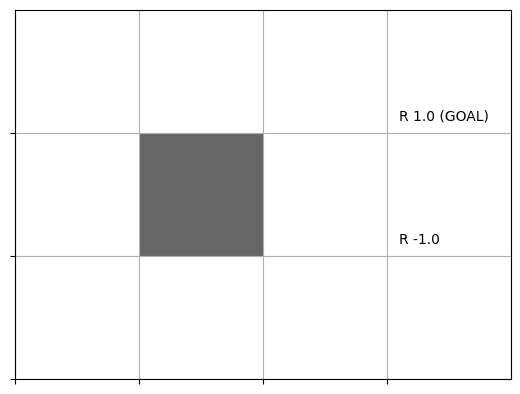

In [10]:
env = GridWorld()
env.render_v()

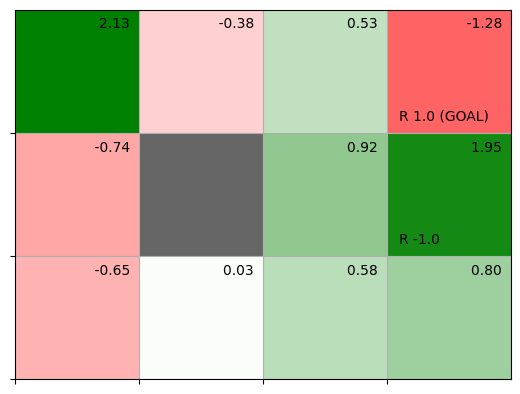

In [11]:
# ダミーの状態価値観数を与えて描画
env = GridWorld()
V = {}
for state in env.states():
    V[state] = np.random.randn() # ダミーの状態価値
env.render_v(v=V)

In [12]:
# defaultdict
from collections import defaultdict
V = defaultdict(lambda: 0)
print(V[(1,2)])

0


In [13]:
# defaultdictで方策(確率分布)を作成
pi = defaultdict(lambda: {0:.25, 1:.25, 2:.25, 3:.25})
state = (0,1)
print(pi[state]) # 状態(0,1)における方策π

{0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}


#### 反復方策評価の実装

In [14]:
# 1ステップだけ更新する関数
def eval_onestep(pi, V, env, gamma=0.9):

    # 全状態を確認
    for state in env.states(): # 1. 各状態へアクセス
        if state == env.goal_state: # 2. ゴールの価値観数は常に0
            V[state] = 0
            continue
    
        action_probs = pi[state] # 方策 p(a|s) ~ π
        new_V = 0

        # 3. 各行動にアクセス
        for action, action_prob in action_probs.items():
            # p(s'|s,a): s'=f(s,a), 状態価値の更新
            next_state = env.next_state(state, action) # ここでは状態遷移は決定論的

            # 報酬 r(s,a,s')
            r = env.reward(state, action, next_state) # 今回は next_stateのみ関与
            
            # 4. 新しい価値関数: 状態Sにおいて次の取りえる状態S'における状態価値を方策で重み付けして加算
            new_V += action_prob * (r + gamma * V[next_state])

        V[state] = new_V

    return V

In [15]:
# 状態価値の更新アルゴリズム(全体)
def policy_eval(pi, V, env, gamma, threshold=0.001):
    # 評価を繰り返す
    while True:
        old_V = V.copy() # 更新前の価値関数
        V = eval_onestep(pi, V, env, gamma)

        # 最大更新量を取得
        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        # 閾値との比較
        if delta < threshold:
            break
    
    return V

反復方策評価の実行

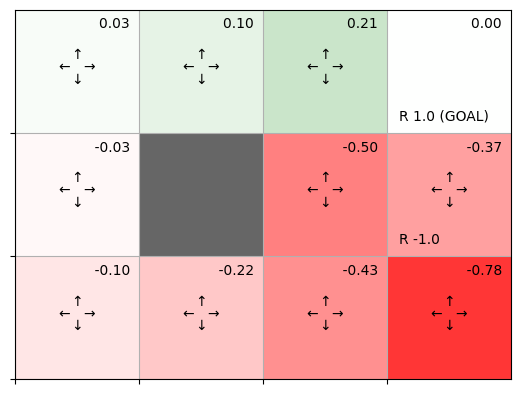

In [16]:
env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: { 0:.25, 1:.25, 2:.25, 3:.25 })
V = defaultdict(lambda: 0)

V = policy_eval(pi, V, env, gamma)
env.render_v(V,pi)

### 反復方策法
+ 狙い：最適方策を求める
+ ベルマン最適方程式を解くのは計算量的に無理. 状態数$S_n$, 行動数$A_n$ => $O(A_n^{S_n})$
#### 最適方策を求める方針
1. 方策評価を行う : 今回は動的計画法(反復方策評価)
2. 方策の改善
3. 1と2を繰り返す

#### 方策の改善
+ 方策のgreedy化によって状態価値関数は必ず改善する

#### 改善の方針
+ 各状態Sにおいて、行動Aの中で最大の行動価値関数maxQとなるものを選べば良い

##### 補足
+ 状態価値関数: その状態の度合い
+ 行動価値関数: 行動に対する良手,悪手の度合い

In [17]:
def argmax(d: dict):
    max_value = max(d.values())
    max_key = 0
    for key, value in d.items():
        if value == max_value:
            max_key = key
    return max_key

In [18]:
action_values = {
    0: 0.1,
    1: -0.3,
    2: 9.9, # max
    3: -1.3,
}

max_action = argmax(action_values)
print(max_action, action_values[max_action])

2 9.9


In [19]:
# 状態価値をgreedy化する関数
def greedy_policy(V: dict, env: GridWorld, gamma: float):
    pi = {}

    for state in env.states():
        action_values = {}
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            # ここ
            value = r + gamma * V[next_state]
            action_values[action] = value # 状態Sにおける行動Aとその時の行動価値Q: p(s'|s,a) * {r(s,a,s') * gamma * V(s')}
            max_action = argmax(action_values)
            # 決定論的
            action_probs = {
                0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0
            }
            action_probs[max_action] = 1.0
            pi[state] = action_probs # { (0,1): { 0:0.0, 1:1.0, 2:0.0, 3:0.0 }, ... }
    
    return pi # 方策



方策評価と方策改善の繰り返し

In [20]:
def policy_iter(env: GridWorld,
                gamma: float,
                threshold: float=0.001,
                is_render: bool=False):
    pi = defaultdict(lambda: { 0:.25, 1:.25, 2:.25, 3:.25 })
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold) # 方策評価
        new_pi = greedy_policy(V, env, gamma) # 方策改善

        if is_render:
            env.render_v(V, pi)
        
        if new_pi == pi: # 更新チェック
            break

        pi = new_pi

    return pi

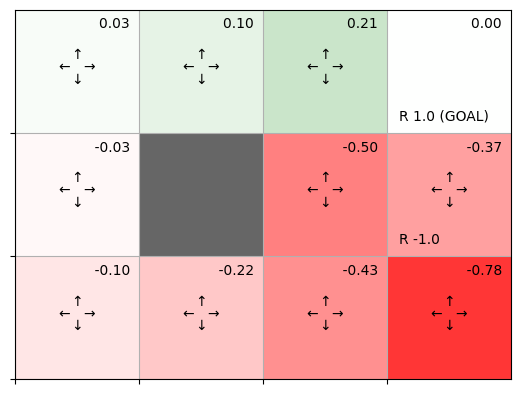

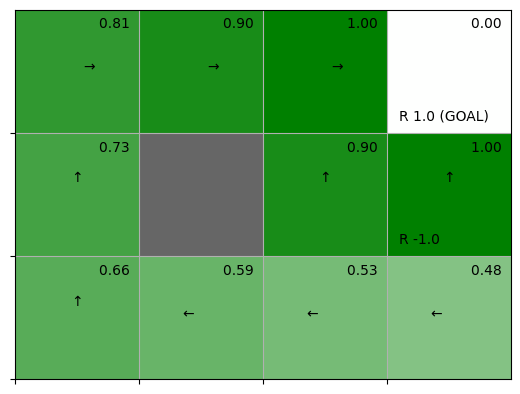

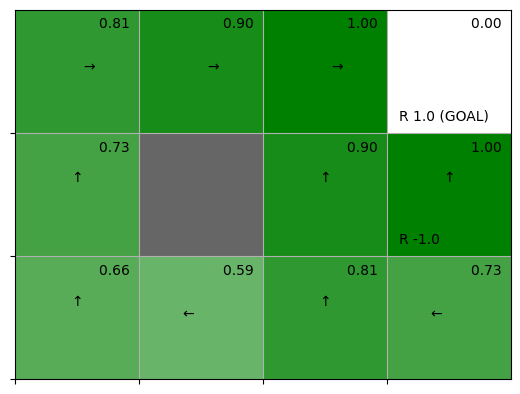

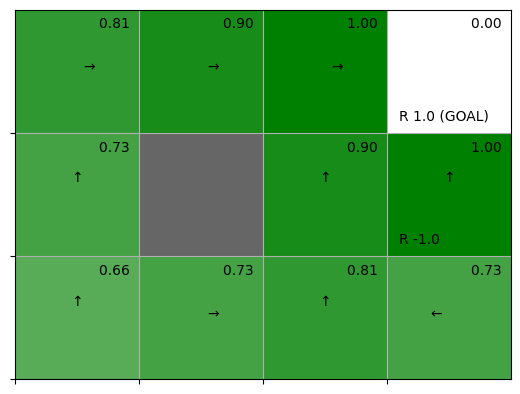

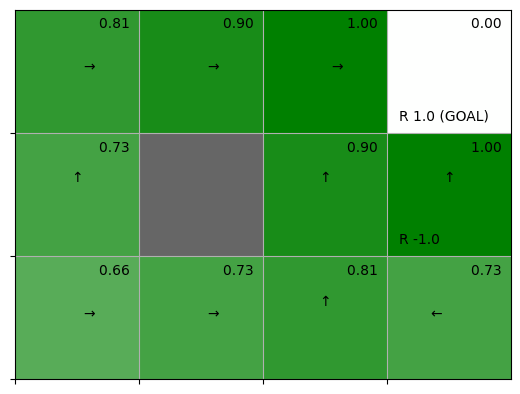

In [21]:
# 最適方策を求める
env = GridWorld()
gamma = 0.9
pi = policy_iter(env, gamma, is_render=True)

#### 方策反復法
+ 幅優先探索
1. 全状態を更新(k回->収束)
2. 全状態における方策を一気に改善
3. 1,2を繰り返す

### 価値反復法
+ 深さ優先探索
1. ある一つの状態を更新
2. その状態についての方策を改善
3. 1と2を状態の数だけ行う
4. 1,2,3を繰り返す
+ 前提：方策改善がgreedyであること?
+ 方策を使わずに「価値評価」と「価値改善」を一つの更新式で実現可能



In [22]:
# 価値反復法の1ステップ
def value_iter_onestep(V, env, gamma):
    # 1. 全ての状態にアクセス
    for state in env.states():
        # ゴールの価値関数は常に0
        if state == env.goal_state:
            V[state] = 0
            continue

        action_values = []
        # 2. 全ての行動にアクセス
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            # 3. 新しい価値関数
            value = r + gamma * V[next_state]
            action_values.append(value)
        
        # 4. 最大値を取り出す
        V[state] = max(action_values)

    return V

In [23]:
# value_iter_onestep関数による更新と収束までの繰り返し
def value_iter(V, env, gamma, threshold=0.001, is_render=True):
    while True:
        if is_render:
            env.render_v(V)
        
        old_V = V.copy() # 更新前の状態価値
        V = value_iter_onestep(V, env, gamma)

        # 更新量を得る
        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        # 閾値と比較
        if delta < threshold:
            break

    return V

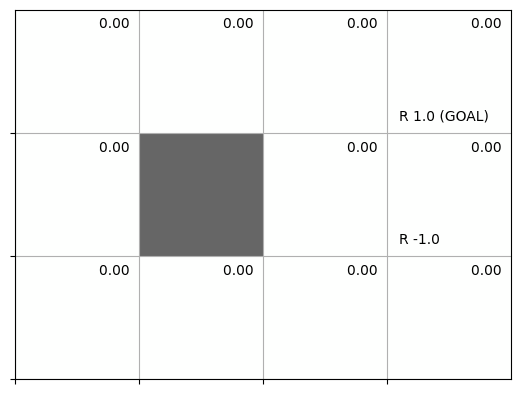

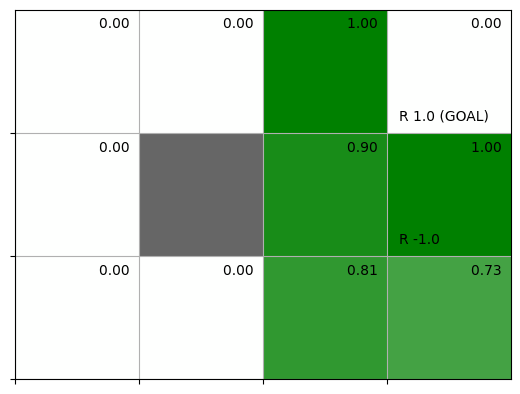

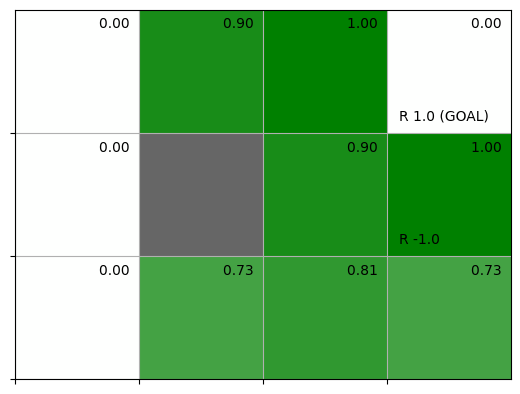

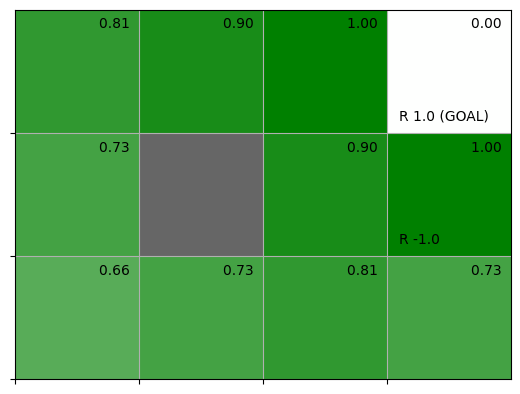

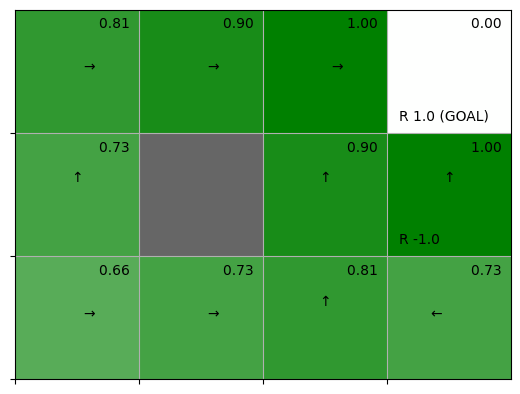

In [24]:
# 価値反復法を3x4グリッドワールドに適用
V = defaultdict(lambda: 0)
env = GridWorld()
gamma = 0.9

V = value_iter(V, env, gamma) # 最適状態価値

pi = greedy_policy(V, env, gamma) # 最適状態価値がわかれば最適方策がわかる

env.render_v(V, pi)